# DTGS186. Figure 1f: Simulating Synapses (Colocalization)

This notebook simulates a two-channel colocalization-microscopy image with DeepTrack2, reproducing the synapse panel of Figure 1f. Ellipsoidal synaptic puncta are rendered in two spectrally distinct channels (`ch0`, `ch1`) that share the same shape and orientation but are offset from one another by a small, random displacement, mimicking pre- and post-synaptic marker pairs. Each channel is composited over a shared filament background and corrupted with independent noise. It generates two matching panels: the dual-color composite image, and the ground-truth channel-overlap mask used to generate it.


In [1]:
# !pip install deeptrack  # Uncomment if running on Colab/Kaggle.


In [2]:
import random

import numpy as np
from matplotlib import pyplot as plt
from scipy.ndimage import gaussian_filter

import deeptrack as dt
from deeptrack.backend.units import get_active_voxel_size


def seed_everything(seed: int = 123) -> None:
    random.seed(seed)
    np.random.seed(seed)


SEED = 234
seed_everything(SEED)

TILE_SIZE = 160
offset_fraction_range = (0.0, 0.5)
snr_range = (3.0, 3.0)

# Physically corrected parameters: 100 nm/px is Nyquist-sampled for NA=1.3 at
# these wavelengths.
RESOLUTION = 1e-7


/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cmanzo/Documents/GitHub/Environments/deeptrack_fixes/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Building the Shared Background Textures

`create_background` produces a smooth, low-frequency intensity fluctuation and `create_fil_background` draws a set of randomly curved filaments, both used later to add realistic, non-uniform background to each channel. `random_ellipsoid_axes` draws the three semi-axes of a synaptic punctum at a physically realistic sub-micron scale.


In [3]:
def create_background(scale=8.0, inty=0.20, size=TILE_SIZE):
    bg = np.random.standard_normal((size, size, 1)).astype(np.float32)
    bg = inty * gaussian_filter(bg, sigma=scale)
    bg[bg < 0] = 0
    return bg.astype(np.float32)


def make_bg(scale=8.0, inty=0.20, size=TILE_SIZE):
    return dt.Value(lambda: create_background(scale=scale, inty=inty, size=size))


def create_fil_background(n_filaments=20, fil_length=40, fil_width=1.5, fil_intensity=0.3,
                           size=256, curvature=0.05):
    fil_layer = np.zeros((size, size), dtype=np.float32)
    for _ in range(n_filaments):
        r0 = np.random.randint(0, size)
        c0 = np.random.randint(0, size)
        angle = np.random.uniform(0, np.pi)
        length = np.random.randint(fil_length // 2, fil_length)
        r, c = float(r0), float(c0)
        for t in range(int(length)):
            angle += np.random.normal(0, curvature)  # gentle random walk in direction
            r += np.sin(angle)
            c += np.cos(angle)
            ri, ci = int(r), int(c)
            if 0 <= ri < size and 0 <= ci < size:
                fil_layer[ri, ci] += 1.0
    fil_layer = gaussian_filter(fil_layer, sigma=fil_width)
    if fil_layer.max() > 0:
        fil_layer = fil_layer / fil_layer.max() * fil_intensity
    return fil_layer[..., np.newaxis].astype(np.float32)


def make_fil(n_filaments=20, fil_length=40, fil_width=1.5, fil_intensity=0.3, size=TILE_SIZE):
    return dt.Value(lambda: create_fil_background(
        n_filaments=n_filaments, fil_length=fil_length,
        fil_width=fil_width, fil_intensity=fil_intensity, size=size,
    ))


def random_ellipsoid_axes():
    # Corrected to true sub-micron synaptic-punctum scale (~0.2-0.8 um footprint).
    ellipse_area = (np.random.uniform(0.2, 0.8)) ** 2
    radius_ratio = np.random.uniform(0.7, 1.4)
    major_axis = np.sqrt(ellipse_area) * radius_ratio
    minor_axis = np.sqrt(ellipse_area) / radius_ratio
    z_axis = np.sqrt(ellipse_area) * np.random.uniform(0.2, 0.4)
    return (major_axis, minor_axis, z_axis) * dt.units.um


## 2. Defining the Synaptic Puncta and Optics

`ellipse_gt` is the ground-truth punctum: its position, rotation and `number_of_points` are shared by both channels. `ellipse_ch0` and `ellipse_ch1` each reuse its radius and rotation but apply an opposite, randomly-sized `shift` along the direction perpendicular to that rotation, so the two channels' puncta sit symmetrically to either side of the ground-truth position. Two `dt.Fluorescence` optics configurations image the two channels at their respective wavelengths.


In [4]:
ellipse_gt = dt.Ellipsoid(
    radius=random_ellipsoid_axes,
    intensity=1,
    position=lambda: np.random.uniform(10, TILE_SIZE - 10, size=2),
    rotation=lambda: np.random.uniform(0, 2 * np.pi),
    number_of_points=lambda: np.random.randint(10, 15),
)

ellipse_ch0 = dt.Ellipsoid(
    radius=ellipse_gt.radius * [1.0, 0.5, 1.0],
    intensity=lambda radius: (1.0 / (radius[0] * radius[1] * radius[2])) ** (1 / 3) * np.random.uniform(0.3, 0.7),
    rotation=ellipse_gt.rotation,
    other_pos=ellipse_gt.position,
    shift=lambda radius: (
        radius[1] * np.random.uniform(*offset_fraction_range) / dt.units.um   # physical, in um
        / (get_active_voxel_size()[0] * 1e6)                                  # -> pixels, live-synced
    ),
    position=lambda rotation, other_pos, shift: (
        other_pos + [shift * np.sin(rotation + np.pi / 2), shift * np.cos(rotation + np.pi / 2)]
    ),
)
ellipse_ch1 = dt.Ellipsoid(
    radius=ellipse_gt.radius * [1.0, 0.5, 1.0],
    intensity=lambda radius: (1.0 / (radius[0] * radius[1])) ** (1 / 2) * np.random.uniform(0.3, 0.7),
    rotation=ellipse_gt.rotation,
    other_pos=ellipse_gt.position,
    shift=-1.0 * ellipse_ch0.shift,
    position=lambda rotation, other_pos, shift: (
        other_pos + [shift * np.sin(rotation + np.pi / 2), shift * np.cos(rotation + np.pi / 2)]
    ),
)

optics_ch0 = dt.Fluorescence(
    resolution=RESOLUTION, magnification=1, wavelength=488e-9, NA=1.3,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)
optics_ch1 = dt.Fluorescence(
    resolution=RESOLUTION, magnification=1, wavelength=568e-9, NA=1.3,
    output_region=(0, 0, TILE_SIZE, TILE_SIZE),
)


## 3. Building the Shared Geometric Pipeline

Both channels are padded, elastically warped and cropped identically, so that the rendered image and its co-registered binary mask (built below) undergo the exact same deformation.


In [5]:
scene_ch0 = (
    (ellipse_ch0 ^ ellipse_gt.number_of_points)
    >> dt.Pad(px=(5, 5, 5, 5), keep_size=False)
    >> dt.ElasticTransformation(alpha=15, sigma=2, order=1)
    >> dt.CropTight()
)
scene_ch1 = (
    (ellipse_ch1 ^ ellipse_gt.number_of_points)
    >> dt.Pad(px=(5, 5, 5, 5), keep_size=False)
    >> dt.ElasticTransformation(alpha=15, sigma=2, order=1)
    >> dt.CropTight()
)


## 4. Building the Co-Registered Masks

`binmask` collapses the point-cloud rendering to a binary footprint (no erosion, since the true footprint is wanted), producing one ground-truth mask per channel.


In [6]:
def binmask(mask):
    return np.sum(mask, -1, keepdims=True) > 0


mask_ch0 = scene_ch0 >> dt.SampleToMasks(lambda: binmask,
                                        output_region=optics_ch0.output_region,
                                        merge_method="or") >> dt.AsType("float")
mask_ch1 = scene_ch1 >> dt.SampleToMasks(lambda: binmask,
                                        output_region=optics_ch1.output_region,
                                        merge_method="or") >> dt.AsType("float")


## 5. Simulating the Two Imaging Channels

Each channel adds two background-scale layers, a warped filament layer, a uniform offset, Poisson shot noise and Gaussian blur, then clips to the valid range. Channel 1 additionally includes a second, sparser and larger-scale filament layer.


In [7]:
sig_ch0 = optics_ch0(scene_ch0)
pip_ch0 = (
    sig_ch0
    >> dt.Add(make_bg(scale=10, inty=2.0))
    >> dt.Add(make_bg(scale=5, inty=0.3))
    >> dt.Add(make_fil(n_filaments=10, fil_length=5, fil_width=3, fil_intensity=0.5)
              >> dt.ElasticTransformation(alpha=15, sigma=2, order=1))
    >> dt.Add(lambda: np.random.uniform(0, 0.1))
    >> dt.Poisson(snr=lambda: np.random.uniform(*snr_range))
    >> dt.Add(lambda: np.random.uniform(0, 0.1))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.5, 1.0))
    >> dt.Clip(0, 1)
)

sig_ch1 = optics_ch1(scene_ch1)
pip_ch1 = (
    sig_ch1
    >> dt.Add(make_bg(scale=10, inty=1.5))
    >> dt.Add(make_bg(scale=5, inty=0.25))
    >> dt.Add(make_fil(n_filaments=10, fil_length=5, fil_width=3, fil_intensity=0.5)
              >> dt.ElasticTransformation(alpha=15, sigma=2, order=1))
    >> dt.Add(make_fil(n_filaments=5, fil_length=200, fil_width=3, fil_intensity=0.35)
              >> dt.ElasticTransformation(alpha=15, sigma=2, order=1))
    >> dt.Add(lambda: np.random.uniform(0.1, 0.2))
    >> dt.Poisson(snr=lambda: np.random.uniform(*snr_range))
    >> dt.Add(lambda: np.random.uniform(0.0, 0.1))
    >> dt.GaussianBlur(sigma=lambda: np.random.uniform(0.5, 1.0))
    >> dt.Clip(0, 1)
)


## 6. Resolving the Scene

Both channels and their masks are resolved together from a single combined pipeline, so the same random draws underlie the images and their annotations.


In [8]:
pip = pip_ch0 & pip_ch1 & mask_ch0 & mask_ch1
pip.update()

ch0, ch1, mask0, mask1 = pip.resolve()

ch0 = ch0.squeeze().astype(np.float32)
ch1 = ch1.squeeze().astype(np.float32)
mask0 = mask0.squeeze().astype(bool)
mask1 = mask1.squeeze().astype(bool)


## 7. Plotting the Composite Image

The two channels are combined into a colorblind-friendly dual-color composite: green for `ch0` and magenta for `ch1`. Green/magenta overlays remain distinguishable across red-green color-vision deficiencies, unlike the conventional red/green pairing (Wong, B. "Points of view: Color blindness." *Nat Methods* 8, 441 (2011)).


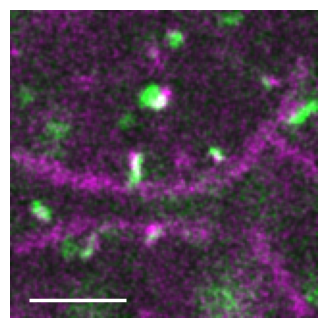

In [9]:
composite = np.zeros((*ch0.shape, 3), dtype=np.float32)
composite[..., 1] = ch0              # green channel <- ch0
composite[..., 0] = ch1              # magenta = red + blue <- ch1
composite[..., 2] = ch1
composite = np.clip(composite, 0, 1)

px_per_um = 1.0 / (RESOLUTION * 1e6)   # RESOLUTION is in meters/px
SCALE_BAR_UM = 5.0
scale_bar_px = SCALE_BAR_UM * px_per_um

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(composite)
x0, y0 = TILE_SIZE * 0.06, TILE_SIZE * 0.94
ax.plot([x0, x0 + scale_bar_px], [y0, y0], color="white", linewidth=2.5,
        solid_capstyle="butt")
ax.axis("off")

fig.savefig("fig1f_synapses_sim.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)


## 8. Plotting the Ground-Truth Overlap

The channel-overlap ground truth marks pixels belonging only to `ch0`, only to `ch1`, or to both (true colocalization), with the ground-truth punctum centers overlaid as open squares.


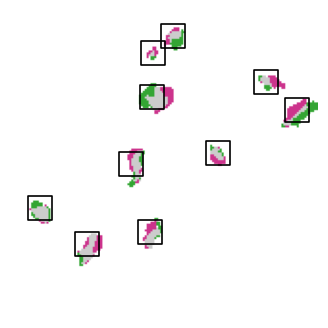

In [10]:
COLOR_CH0 = [0.20, 0.65, 0.20]  # green, ch0-only
COLOR_CH1 = [0.80, 0.20, 0.55]  # magenta, ch1-only

composite_gt = np.ones((*mask0.shape, 3), dtype=np.float32)
composite_gt[mask0] = COLOR_CH0
composite_gt[mask1] = COLOR_CH1
composite_gt[mask0 & mask1] = [0.80, 0.80, 0.80]   # true overlap

pos_gt = dt.TakeProperties(scene_ch0, "other_pos")
pos_gt = np.array(pos_gt())

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(composite_gt)
ax.scatter(pos_gt[:, 1], pos_gt[:, 0], s=300,
    facecolors="none",
    edgecolors="black",
    linewidths=1.2,
    marker="s",
    label="ground truth",)
ax.axis("off")

fig.savefig("fig1f_synapses_gt.svg", format="svg", bbox_inches="tight",
            pad_inches=0, transparent=True)
